## Imports

In [24]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
import sys
import tensorflow
import scipy
from matplotlib import pyplot
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adagrad, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.applications import (
    VGG19, VGG16, EfficientNetB7, DenseNet201, ResNet50, 
    InceptionV3, InceptionResNetV2, NASNetLarge
)
from tensorflow.keras.applications.resnet import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras import layers, models, callbacks

In [26]:
train_dir = 'C:/Users/Ramy/Desktop/Stage/Data/Archeozoology/Data/Carnivoresx30/conv/train'        
validation_dir = 'C:/Users/Ramy/Desktop/Stage/Data/Archeozoology/Data/Carnivoresx30/conv/validation' 

In [27]:
physical_devices = tf.config.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)


In [28]:
from tensorflow.keras.applications.resnet import preprocess_input 

#from keras.applications.imagenet_utils import decode_predictions, preprocess_input#for efficient Net
def to_grayscale_then_preprocess(img):
    img = img.astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)          # Convert to grayscale (1 channel)
    gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)      # Convert back to 3 channels
    return tf.keras.applications.resnet.preprocess_input(gray_3ch.astype(np.float32))
#Let's train our network using data augmentation and dropout:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=to_grayscale_then_preprocess,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

# Note that the validation data should not be augmented!
test_datagen = ImageDataGenerator(preprocessing_function= preprocess_input)#OJO!!!

train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized 
        target_size=(250, 200),
        batch_size=32,
        class_mode='categorical',# put "categorical" si son más de 2 categorías
)

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(250, 200),
        batch_size=20,
        class_mode='categorical',
        shuffle=False,
)

Found 1170 images belonging to 5 classes.
Found 390 images belonging to 5 classes.


In [29]:
import cv2
x_tr, y_tr = next(train_generator)
x_t, y_t = next(validation_generator)
print(x_tr.shape, 'train samples')
print(x_t.shape, 'test samples')

(32, 250, 200, 3) train samples
(20, 250, 200, 3) test samples


In [30]:
datagenTrain=train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 40x160
        target_size=(250,200),
        batch_size=939,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='categorical')
datagenTest=test_datagen.flow_from_directory(
        # This is the target directory
        validation_dir,
        # All images will be resized to 40x160
        target_size=(250, 200),
        batch_size=313,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='categorical',
        shuffle=False)
x_train, y_train = next(datagenTrain)
x_test, y_test = next(datagenTest)
print(x_train.shape, 'train samples')
print(x_test.shape, 'test samples')

Found 1170 images belonging to 5 classes.
Found 390 images belonging to 5 classes.
(939, 250, 200, 3) train samples
(313, 250, 200, 3) test samples


## Choix du Modèle ##

## Running the Model ##

In [31]:
# Import the correct function for loading a Keras model
from tensorflow.keras.models import load_model

# Load the model from the specified path (use raw string or double backslashes)
model = load_model(r'C:\Users\Ramy\Desktop\Stage\Script\RESNET new data\ResNet50_NewData.h5')
    

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import math

# Calculate exact number of steps to process all validation samples
steps = math.ceil(validation_generator.samples / validation_generator.batch_size)

# Make predictions on the full validation set
predictions = model.predict(validation_generator, steps=steps, verbose=1)

# Convert probabilities to predicted class indices
y_pred = np.argmax(predictions, axis=1)

# Ground truth
y_true = validation_generator.classes

# Check lengths
print("Predicted samples:", len(y_pred))
print("Ground truth samples:", len(y_true))

# Compute confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Optional: detailed classification report
print("\nClassification Report:")
target_names = list(validation_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=target_names))


20/20 [==============================] - 8s 369ms/step
Predicted samples: 390
Ground truth samples: 390

Confusion Matrix:
[[  3   7  10   0   0]
 [  0  74  17   0   0]
 [  0  13 123   0   0]
 [  0   4  21  41   0]
 [  1   7  19   1  49]]

Classification Report:
              precision    recall  f1-score   support

         CFP       0.75      0.15      0.25        20
        HESP       0.70      0.81      0.76        91
        LPZP       0.65      0.90      0.75       136
         LZP       0.98      0.62      0.76        66
     Lycaons       1.00      0.64      0.78        77

    accuracy                           0.74       390
   macro avg       0.82      0.63      0.66       390
weighted avg       0.79      0.74      0.73       390



In [36]:
print('Classification Report')
target_names = ['croc', 'hyena', 'leopard', 'lion','Lycaons']
print(classification_report(validation_generator.classes, y_pred, target_names=target_names))

Classification Report
              precision    recall  f1-score   support

        croc       0.75      0.15      0.25        20
       hyena       0.70      0.81      0.76        91
     leopard       0.65      0.90      0.75       136
        lion       0.98      0.62      0.76        66
     Lycaons       1.00      0.64      0.78        77

    accuracy                           0.74       390
   macro avg       0.82      0.63      0.66       390
weighted avg       0.79      0.74      0.73       390



In [37]:
import matplotlib.pyplot as plt
#PLOT
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy for ResNet50 ')
plt.xlabel('Epochs')    
plt.ylabel('Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss for ResNet50')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

NameError: name 'history' is not defined

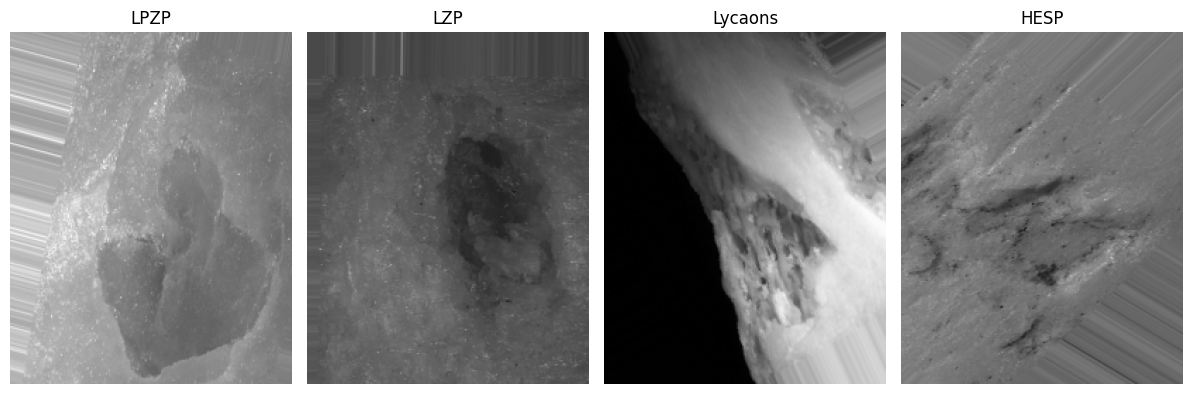

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Reverse the preprocessing (ResNet: add mean, clip to [0,255])
def deprocess_input(x):
    x = x.copy()
    x[..., 0] += 103.939  # B
    x[..., 1] += 116.779  # G
    x[..., 2] += 123.68   # R
    x = np.clip(x, 0, 255).astype(np.uint8)
    return x

# Get one batch from train_generator
x_batch, y_batch = next(train_generator)

# Get class labels from generator
class_labels = list(train_generator.class_indices.keys())

# Track which classes we've shown
shown_classes = set()

# Display up to 5 images, one per class
plt.figure(figsize=(15, 4))
shown = 0
for i in range(len(x_batch)):
    class_index = np.argmax(y_batch[i])
    class_name = class_labels[class_index]

    if class_name not in shown_classes:
        img = deprocess_input(x_batch[i])  # Reverse ResNet preprocessing
        plt.subplot(1, 5, shown + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
        shown_classes.add(class_name)
        shown += 1

    if shown == 5:
        break

plt.tight_layout()
plt.show()
